In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [7]:
# define lorenz equations
def lorenz(t, state, sigma=10, rho=28, beta=8/3):
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return [dx, dy, dz]

In [8]:
# solve the lorenz system
# Initial conditions and time
state0 = [1.0, 1.0, 1.0]  # starting point [x, y, z]
t_span = (0, 50)           # simulate from t=0 to t=50
t_eval = np.linspace(0, 50, 10000)  # 10000 time steps

# Solve!
solution = solve_ivp(lorenz, t_span, state0, t_eval=t_eval)

print(solution.message)

The solver successfully reached the end of the integration interval.


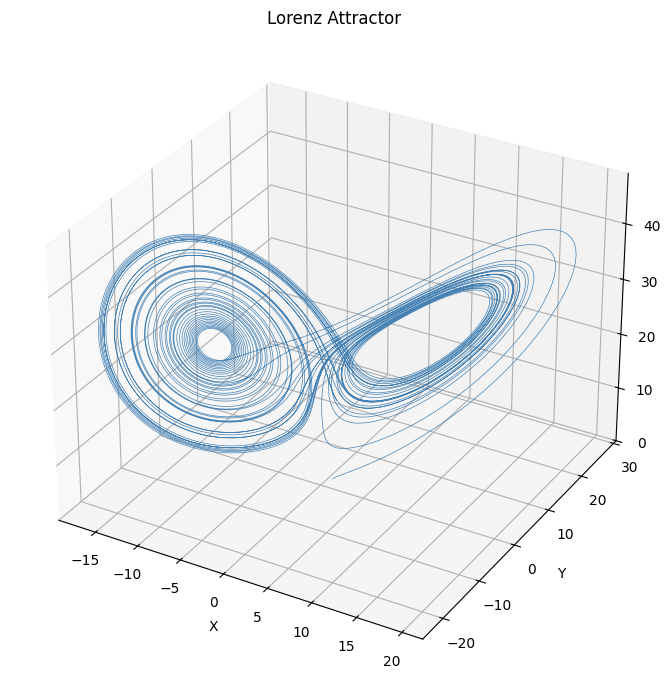

In [9]:
# plot the results
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot(solution.y[0], solution.y[1], solution.y[2], 
        lw=0.5, color="steelblue")

ax.set_title("Lorenz Attractor")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.tight_layout()
plt.show()

In [10]:
# Two starting points very close to each other
state0_a = [1.0, 1.0, 1.0]
state0_b = [1.0 + 0.0001, 1.0, 1.0]  # just 0.0001 difference in x

# Solve both
sol_a = solve_ivp(lorenz, t_span, state0_a, t_eval=t_eval)
sol_b = solve_ivp(lorenz, t_span, state0_b, t_eval=t_eval)

# Calculate the distance between the two trajectories over time
distance = np.sqrt((sol_a.y[0] - sol_b.y[0])**2 + 
                   (sol_a.y[1] - sol_b.y[1])**2 + 
                   (sol_a.y[2] - sol_b.y[2])**2)

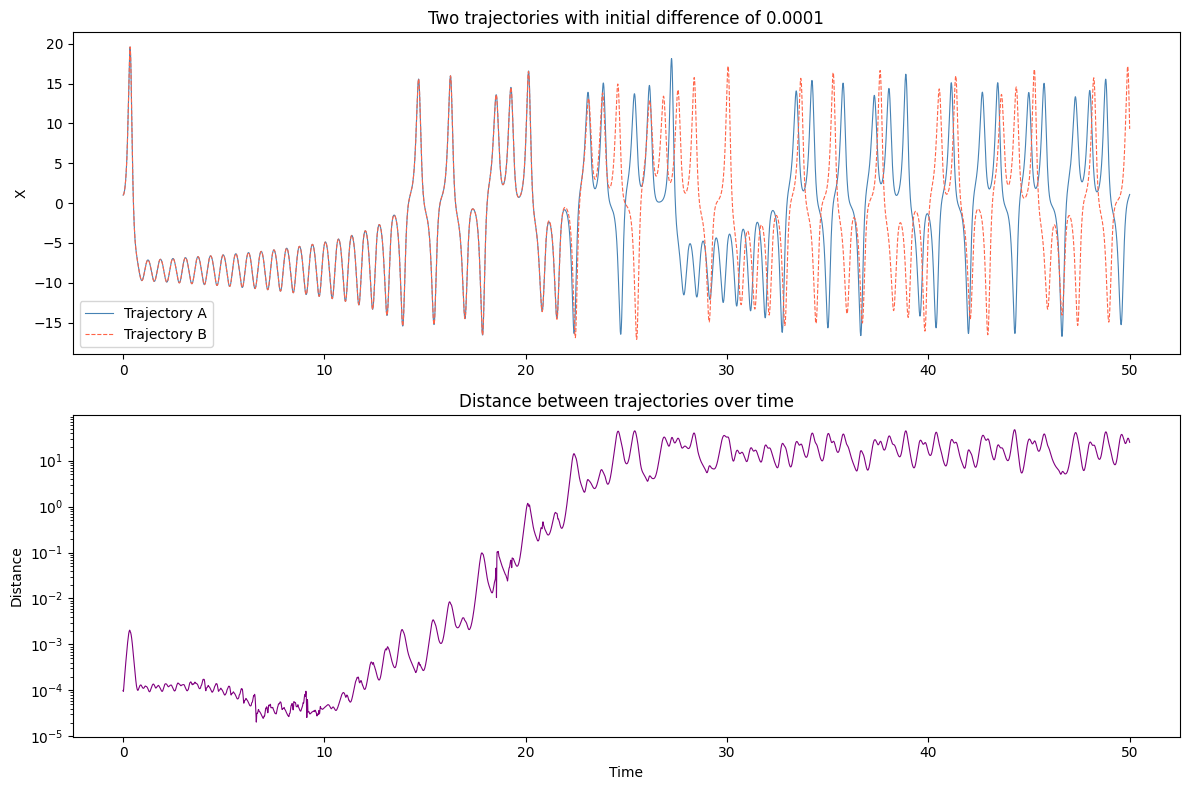

In [13]:
#plot the distance on log scale
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Top panel: x over time for both trajectories
axes[0].plot(t_eval, sol_a.y[0], color="steelblue", lw=0.8, label="Trajectory A")
axes[0].plot(t_eval, sol_b.y[0], color="tomato", lw=0.8, label="Trajectory B", linestyle="--")
axes[0].set_title("Two trajectories with initial difference of 0.0001")
axes[0].set_ylabel("X")
axes[0].legend()

# Bottom panel: distance between trajectories over time
axes[1].plot(t_eval, distance, color="purple", lw=0.8)
axes[1].set_yscale("log")
axes[1].set_title("Distance between trajectories over time")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Distance")

plt.tight_layout()
plt.show()